In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct


import funciones_aux as fau

import funciones_dsa as fun_dsa
import funciones_dsa_unilateral as fun_dsa_u
import funciones_dsa_bilateral as fun_dsa_b

import funciones_plot_dsa as fun_plot

from scipy.signal import welch
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.stats import pearsonr, spearmanr


# 1. Unilateral

In [2]:
ruta_fa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.f_a"
ruta_spa_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
ruta_ha_unilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a"

archivo_r2a = r"C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

## 1. 1.  Archivo Espectral .f_a

In [3]:
tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa_unilat, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz


## 1. 2. Archivo variables procesadas .spa

In [4]:
df_spa_raw = fau.procesar_spa(ruta_spa_unilat)
df_spa_unilat = fun_dsa_u.limpiar_spa_unilateral(df_spa_raw)

print("Dimensiones del archivo procesado:", df_spa_unilat.shape)

Dimensiones del archivo procesado: (2119, 11)


### Fusión de los anteriores

In [5]:
df_merge_fa = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_fa["SEF08"]
mf_hor = df_merge_fa["MEDFRQ08"]

dsa_plot_fa, mask_total_fa = fun_dsa.preparar_dsa_con_mask(tiempo_fa_unilat, dsa_unilat, df_merge_fa)


### Cabecera

In [6]:
num_canales, fs, pendiente, offset = fau.extraer_parametros_eeg(ruta_ha_unilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales}")
print(f" - Frecuencia (Hz): {fs}")
print(f" - Pendiente (m): {pendiente:.8f}")
print(f" - Offset (b): {offset:.4f}")

Parámetros extraídos con éxito:
 - Canales: 2
 - Frecuencia (Hz): 128
 - Pendiente (m): 0.05000000
 - Offset (b): -3234.0000


## 1. 3 Archivo ondas crudas .r2a

In [7]:
df_eeg = fun_dsa_u.leer_r2a(
    archivo_r2a,
    pendiente,
    offset,
    fs=fs
)

# 2. Bilateral - Advanced

In [8]:
ruta_fa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.f_a"
ruta_spa_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.spa"
ruta_ha_bilat = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.h_a"

archivo_r4a = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/L05141322/L05141322.r4a"

## 2. 1. Archivo Espectral .f_a

In [9]:
tiempo_fa_bilat, dsa_fa_L, dsa_fa_R = fau.cargar_fa_bilateral(
    ruta_fa_bilat,
    escalar_db=True
)

print("Dimensiones del archivo hemisferio izquierdo:", dsa_fa_L.shape)
print("Dimensiones del archivo hemisferio derecho:", dsa_fa_R.shape)

Dimensiones del archivo hemisferio izquierdo: (2712, 60)
Dimensiones del archivo hemisferio derecho: (2712, 60)


## 2. 2. Archivo variables procesadas .spa

In [10]:
df_spa_raw_bilat = fau.procesar_spa(ruta_spa_bilat)
df_spa_bilat = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_bilat)

print("Dimensiones del archivo procesado:", df_spa_bilat.shape)
print(df_spa_bilat.columns.tolist())
#display(df_spa_bilat.head())

Dimensiones del archivo procesado: (2712, 31)
['Time', 'SR12_izq', 'SEF08_izq', 'MEDFRQ08_izq', 'BISBIT00_izq', 'DB13U01_izq', 'DB11U04_izq', 'B34U05_izq', 'TOTPOW08_izq', 'EMGLOW01_izq', 'SQI10_izq', 'IMPEDNCE_izq', 'ARTF2_izq', 'BURST_izq', 'ST_izq', 'SR12_der', 'SEF08_der', 'MEDFRQ08_der', 'BISBIT00_der', 'DB13U01_der', 'DB11U04_der', 'B34U05_der', 'TOTPOW08_der', 'EMGLOW01_der', 'SQI10_der', 'IMPEDNCE_der', 'ARTF2_der', 'BURST_der', 'ST_der', 'ASYM09', 'modo_spa']


### Fusión de los anteriores

In [11]:
df_merge_fa_bilat = fun_dsa.alinear_spa_con_tiempo(
    tiempo_fa_bilat,
    df_spa_bilat
)

In [12]:
# Extraer cada hemisferio con nombres estándar
df_spa_L = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="izq",
    verbose=False
)

df_spa_R = fun_dsa_b.extraer_lado_spa_bilateral(
    df_spa_bilat,
    lado="der",
    verbose=False
)

# Alinear cada lado con el tiempo del .f_a bilateral
df_merge_fa_L = fun_dsa.alinear_spa_con_tiempo(
    tiempo_fa_bilat,
    df_spa_L
)

df_merge_fa_R = fun_dsa.alinear_spa_con_tiempo(
    tiempo_fa_bilat,
    df_spa_R
)

# Curvas del BIS por hemisferio
sef_fa_L = df_merge_fa_L["SEF08"]
mef_fa_L = df_merge_fa_L["MEDFRQ08"]

sef_fa_R = df_merge_fa_R["SEF08"]
mef_fa_R = df_merge_fa_R["MEDFRQ08"]

# Preparar DSA .f_a izquierda y derecha con sus máscaras
dsa_plot_fa_L, mask_total_fa_L = fun_dsa.preparar_dsa_con_mask(
    tiempo_fa_bilat,
    dsa_fa_L,
    df_merge_fa_L
)

dsa_plot_fa_R, mask_total_fa_R = fun_dsa.preparar_dsa_con_mask(
    tiempo_fa_bilat,
    dsa_fa_R,
    df_merge_fa_R
)

# Máscara común para comparar ambos hemisferios visualmente
mask_total_fa_bilat = mask_total_fa_L | mask_total_fa_R

dsa_plot_fa_L_mask = dsa_plot_fa_L.copy()
dsa_plot_fa_R_mask = dsa_plot_fa_R.copy()

dsa_plot_fa_L_mask.loc[mask_total_fa_bilat.values, :] = np.nan
dsa_plot_fa_R_mask.loc[mask_total_fa_bilat.values, :] = np.nan

In [13]:
frecuencias_fa = dsa_plot_fa_L_mask.columns.astype(float)

In [15]:
matriz_fa_L, matriz_fa_R, vmin_fa, vmax_fa, norm_fa_bilat, cmap_fa_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_plot_fa_L_mask,
        dsa_plot_fa_R_mask,
        vmin=49,
        vmax=94,
        gamma=1
    )
)

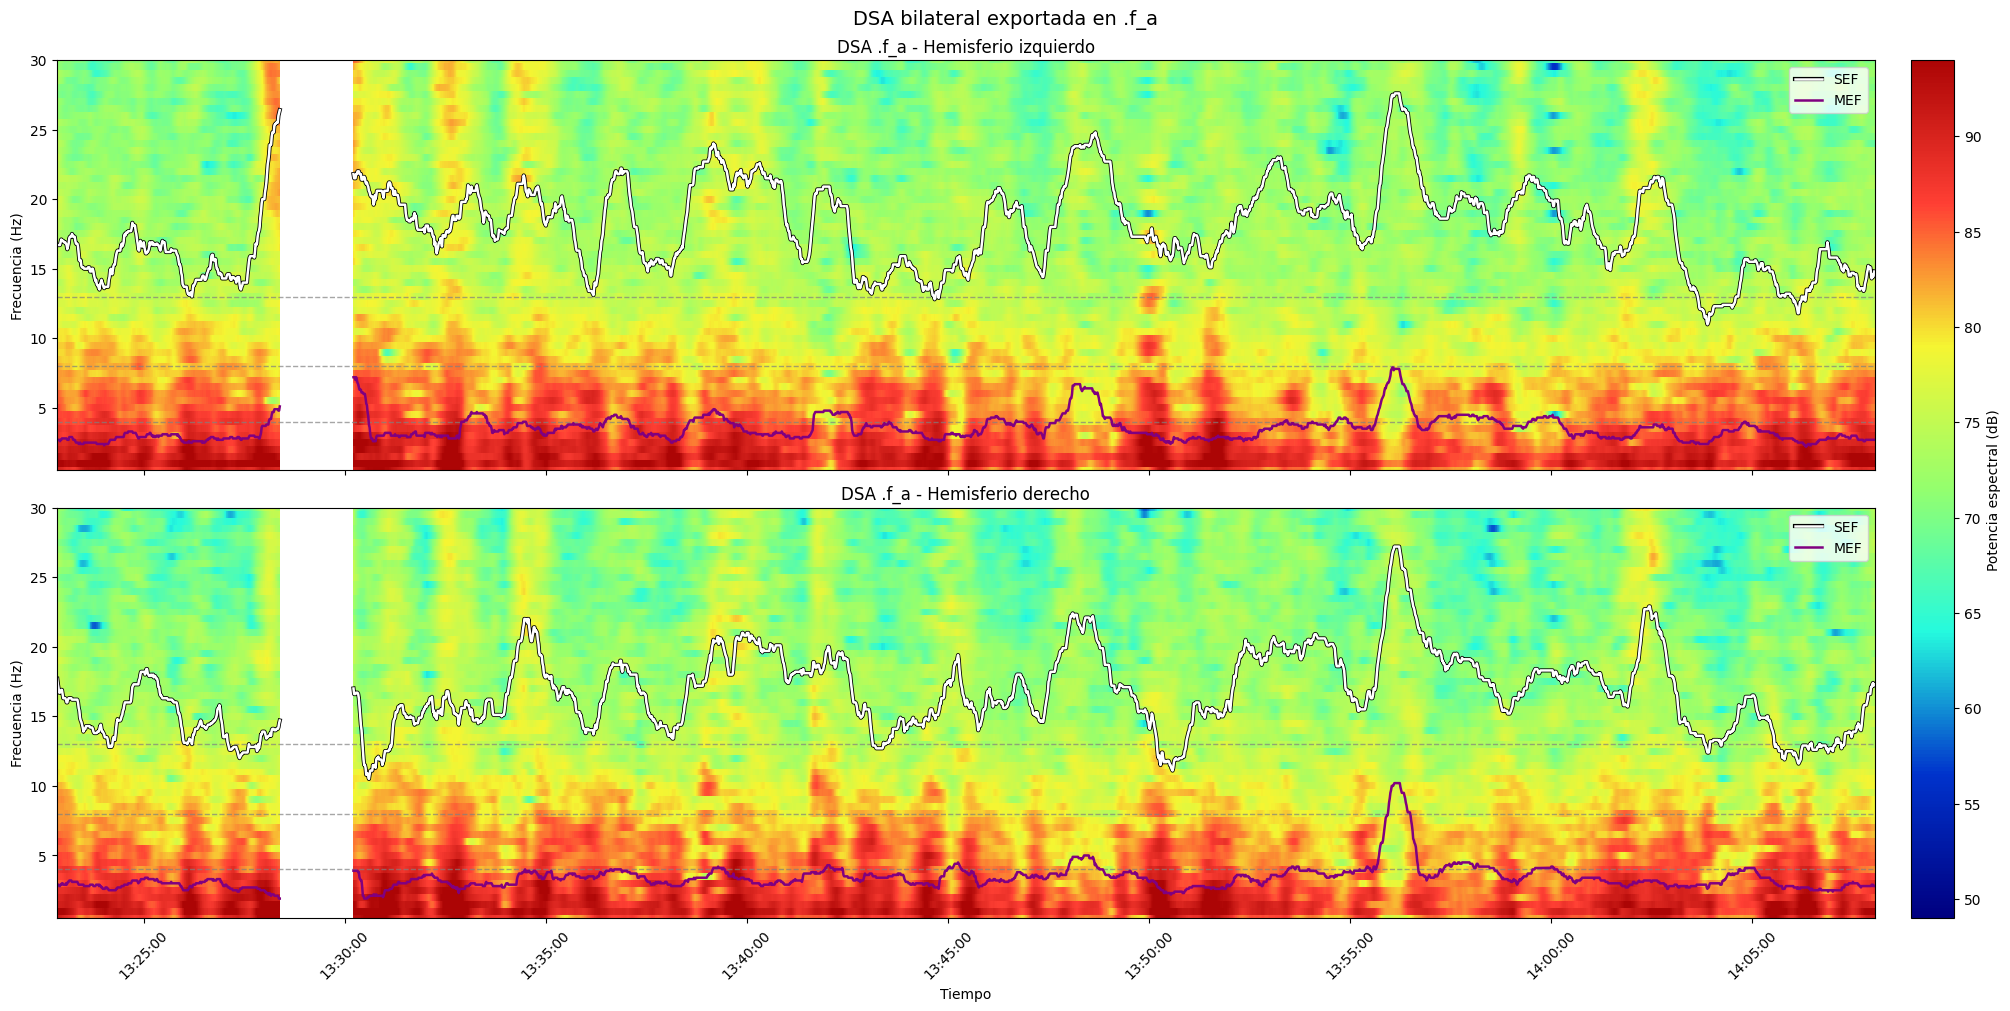

In [18]:
fig, axes = fun_plot.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo_fa_bilat,
    frecuencias=dsa_plot_fa_L_mask.columns.astype(float),
    matriz_izq=matriz_fa_L,
    matriz_der=matriz_fa_R,
    norm=norm_fa_bilat,
    cmap=cmap_fa_bilat,
    df_merge_izq=df_merge_fa_L,
    df_merge_der=df_merge_fa_R,
    mask_izq=mask_total_fa_bilat,
    mask_der=mask_total_fa_bilat,
    titulo_izq="DSA .f_a - Hemisferio izquierdo",
    titulo_der="DSA .f_a - Hemisferio derecho",
    titulo_general="DSA bilateral exportada en .f_a",
    etiqueta_colorbar="Potencia espectral (dB)"
)

### Cabecera

In [ ]:
num_canales_bil, fs_bil, pendiente_bil, offset_bil = fau.extraer_parametros_eeg(ruta_ha_bilat)
print("Parámetros extraídos con éxito:")
print(f" - Canales: {num_canales_bil}")
print(f" - Frecuencia (Hz): {fs_bil}")
print(f" - Pendiente (m): {pendiente_bil:.8f}")
print(f" - Offset (b): {offset_bil:.4f}")

## 2. 3. Archivo ondas crudas .r4a

In [ ]:
df_eeg_bilateral = fun_dsa_b.leer_r4a(
    archivo_r4a, 
    pendiente_bil,
    offset_bil, 
    fs=fs_bil)

### 2. 3. 1. Reconstrucción

### 2. 3. 2. Adaptación temporal, máscara y plot de DSA EEG

### 2. 3. 3. Preparar escala de color de f_a y eeg reconstruida

In [ ]:
matriz_eeg_L, matriz_eeg_R, vmin_eeg, vmax_eeg, norm_eeg_bilat, cmap_eeg_bilat = (
    fun_dsa_b.preparar_escala_color_dsa_bilateral(
        dsa_eeg_L_plot,
        dsa_eeg_R_plot,
        gamma=0.55,
        percentil_min=2,
        percentil_max=99.5
    )
)

### 2. 3. 4. Visualizar reconstruidas desde .r4a

In [ ]:
ruta_spa_bilat_h = "C:/Users/usuario/TFG_BIS_GIS/data/data_bis_advanced/bilateral/M-Py5D-04301923\DH04301923\L04301923.spa"
df_spa_raw_h = fau.procesar_spa(ruta_spa_bilat_h)

df_spa_limpio_h = fun_dsa_b.limpiar_spa_bilateral(df_spa_raw_h)


display(df_spa_limpio_h.head())